In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\benso\.cache\kagglehub\datasets\olistbr\brazilian-ecommerce\versions\2


In [3]:
dataset_path = r"C:\Users\benso\.cache\kagglehub\datasets\olistbr\brazilian-ecommerce\versions\2"

dataframes = {}

for file in os.listdir(dataset_path):
    if file.endswith('.csv'):
        name = file.replace('.csv', '')
        dataframes[name] = pd.read_csv(os.path.join(dataset_path, file))

print(dataframes.keys())

dict_keys(['olist_customers_dataset', 'olist_geolocation_dataset', 'olist_orders_dataset', 'olist_order_items_dataset', 'olist_order_payments_dataset', 'olist_order_reviews_dataset', 'olist_products_dataset', 'olist_sellers_dataset', 'product_category_name_translation'])


In [4]:
customers = dataframes['olist_customers_dataset']
geolocation = dataframes['olist_geolocation_dataset']
orders = dataframes['olist_orders_dataset']
order_items = dataframes['olist_order_items_dataset']
order_payments = dataframes['olist_order_payments_dataset']
order_reviews = dataframes['olist_order_reviews_dataset']
products = dataframes['olist_products_dataset']
sellers = dataframes['olist_sellers_dataset']
product_category_translation = dataframes['product_category_name_translation']

In [5]:
tables = {
    "orders": orders,
    "customers": customers,
    "order_items": order_items,
    "products": products,
    "sellers": sellers,
    "payments": order_payments,
    "reviews": order_reviews,
    "geolocation": geolocation,
    "category_translation": product_category_translation
}
print("Table sizes:")
for name, df in tables.items():
    print(f"   {name:<25} {df.shape[0]:>7,} rows  x  {df.shape[1]} columns")

Table sizes:
   orders                     99,441 rows  x  8 columns
   customers                  99,441 rows  x  5 columns
   order_items               112,650 rows  x  7 columns
   products                   32,951 rows  x  9 columns
   sellers                     3,095 rows  x  4 columns
   payments                  103,886 rows  x  5 columns
   reviews                    99,224 rows  x  7 columns
   geolocation               1,000,163 rows  x  5 columns
   category_translation           71 rows  x  2 columns


In [6]:
for name, df in tables.items():
    null_count = df.isnull().sum().sum()
    dup_count  = df.duplicated().sum()
    if null_count > 0 or dup_count > 0:
        print(f"\n  {name}:")
        if null_count > 0:
            nulls = df.isnull().sum()
            print(nulls[nulls > 0].to_string())
        if dup_count > 0:
            print(f"   Duplicate rows: {dup_count}")
    else:
        print(f" {name} — no nulls or duplicates")
 


  orders:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
 customers — no nulls or duplicates
 order_items — no nulls or duplicates

  products:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
 sellers — no nulls or duplicates
 payments — no nulls or duplicates

  reviews:
review_comment_title      87656
review_comment_message    58247

  geolocation:
   Duplicate rows: 261831
 category_translation — no nulls or duplicates


In [7]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])
 
print(" Date columns converted in orders table")
print(f"   Date range: {orders['order_purchase_timestamp'].min().date()} "
      f"→ {orders['order_purchase_timestamp'].max().date()}")
 

 Date columns converted in orders table
   Date range: 2016-09-04 → 2018-10-17


In [8]:
products = products.merge(product_category_translation, on="product_category_name", how="left")

# Handle 3 known untranslatable categories
untranslated = products[products["product_category_name_english"].isnull()]["product_category_name"].unique()
print(f"  Untranslated categories ({len(untranslated)}): {list(untranslated)}")

# Manual fixes for the 3 known missing ones
manual_translations = {
    "pc_gamer": "pc_gamer",
    "portateis_cozinha_e_preparadores_de_alimentos": "portable_kitchen_appliances",
}

products["product_category_name_english"] = products.apply(
    lambda row: manual_translations.get(row["product_category_name"], row["product_category_name_english"])
    if pd.isnull(row["product_category_name_english"]) else row["product_category_name_english"],
    axis=1
)

print("Category names translated to English")

  Untranslated categories (3): [nan, 'pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos']
Category names translated to English


In [9]:
df = (
    orders
    .merge(customers, on="customer_id", how="left")
    .merge(order_items, on="order_id", how="left")
    .merge(products, on="product_id", how="left")
    .merge(sellers, on="seller_id", how="left")
    .merge(order_payments, on="order_id", how="left")
    .merge(order_reviews[["order_id", "review_score"]], on="order_id", how="left")
)
df["order_year"] = df["order_purchase_timestamp"].dt.year
df["order_month"] = df["order_purchase_timestamp"].dt.month
df["order_month_name"] = df["order_purchase_timestamp"].dt.strftime("%b")
print(f" Master dataframe: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"   Unique orders:    {df['order_id'].nunique():,}")
print(f"   Unique customers: {df['customer_id'].nunique():,}")
print(f"   Unique products:  {df['product_id'].nunique():,}")
print(f"   Unique sellers:   {df['seller_id'].nunique():,}")

 Master dataframe: 119,143 rows x 38 columns
   Unique orders:    99,441
   Unique customers: 99,441
   Unique products:  32,951
   Unique sellers:   3,095


In [10]:
#Convert state abbreviations to full names
state_names = {
    'AC': 'Acre', 'AL': 'Alagoas', 'AP': 'Amapá', 'AM': 'Amazonas',
    'BA': 'Bahia', 'CE': 'Ceará', 'DF': 'Brasília', 'ES': 'Espírito Santo',
    'GO': 'Goiás', 'MA': 'Maranhão', 'MT': 'Mato Grosso',
    'MS': 'Mato Grosso do Sul', 'MG': 'Minas Gerais', 'PA': 'Pará',
    'PB': 'Paraíba', 'PR': 'Paraná', 'PE': 'Pernambuco', 'PI': 'Piauí',
    'RJ': 'Rio de Janeiro', 'RN': 'Rio Grande do Norte', 'RS': 'Rio Grande do Sul',
    'RO': 'Rondônia', 'RR': 'Roraima', 'SC': 'Santa Catarina',
    'SP': 'São Paulo', 'SE': 'Sergipe', 'TO': 'Tocantins'
}

df["customer_state"] = df["customer_state"].map(state_names)
seller_state_names = {
    'AC': 'Acre', 'AL': 'Alagoas', 'AP': 'Amapá', 'AM': 'Amazonas',
    'BA': 'Bahia', 'CE': 'Ceará', 'DF': 'Brasília', 'ES': 'Espírito Santo',
    'GO': 'Goiás', 'MA': 'Maranhão', 'MT': 'Mato Grosso',
    'MS': 'Mato Grosso do Sul', 'MG': 'Minas Gerais', 'PA': 'Pará',
    'PB': 'Paraíba', 'PR': 'Paraná', 'PE': 'Pernambuco', 'PI': 'Piauí',
    'RJ': 'Rio de Janeiro', 'RN': 'Rio Grande do Norte', 'RS': 'Rio Grande do Sul',
    'RO': 'Rondônia', 'RR': 'Roraima', 'SC': 'Santa Catarina',
    'SP': 'São Paulo', 'SE': 'Sergipe', 'TO': 'Tocantins'
}
df["seller_state"] = df["seller_state"].map(seller_state_names)

print("State abbreviations converted to full names")

State abbreviations converted to full names


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2


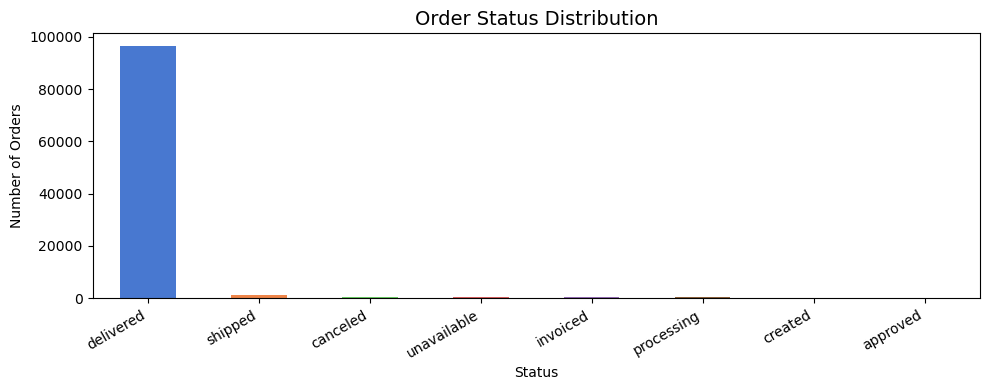

Chart saved: phase1_order_status.png


In [11]:
status_counts = orders["order_status"].value_counts()
print(status_counts.to_string())
 
plt.figure(figsize=(10, 4))
status_counts.plot(kind="bar", color=sns.color_palette("muted"))
plt.title("Order Status Distribution", fontsize=14)
plt.xlabel("Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("phase1_order_status.png", dpi=150)
plt.show()
print("Chart saved: phase1_order_status.png")
 

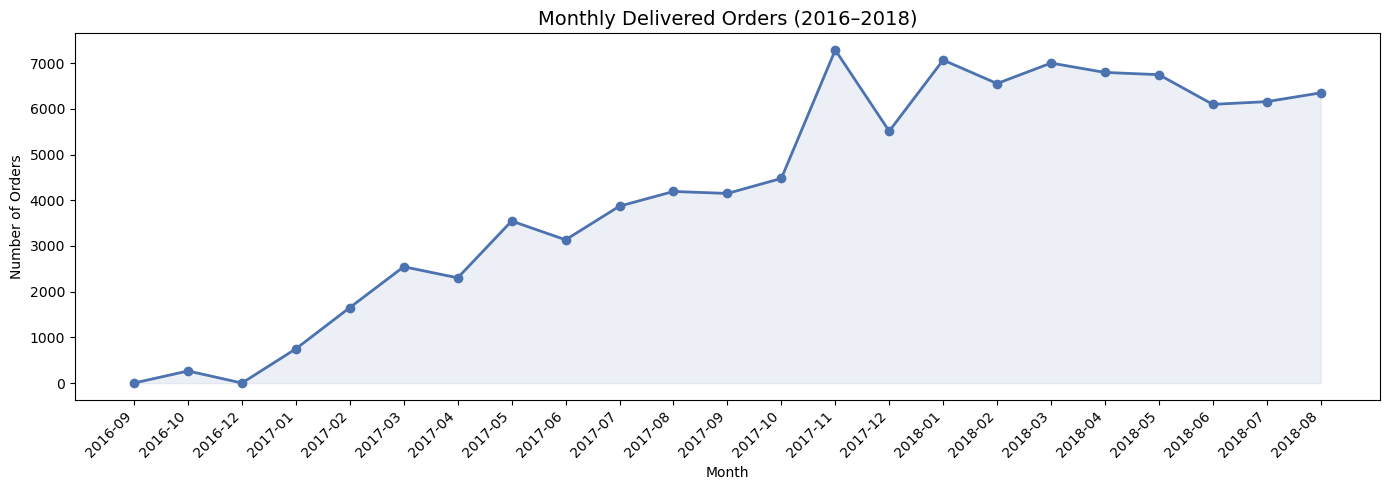

Chart saved: phase1_monthly_orders.png


In [12]:
monthly_orders = (
    orders[orders["order_status"] == "delivered"]
    .groupby(orders["order_purchase_timestamp"].dt.to_period("M"))
    .size()
    .reset_index(name="order_count")
)
monthly_orders["period"] = monthly_orders["order_purchase_timestamp"].astype(str)
 
plt.figure(figsize=(14, 5))
plt.plot(monthly_orders["period"], monthly_orders["order_count"], marker="o", linewidth=2, color="#4C72B0")
plt.fill_between(monthly_orders["period"], monthly_orders["order_count"], alpha=0.1, color="#4C72B0")
plt.title("Monthly Delivered Orders (2016–2018)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("phase1_monthly_orders.png", dpi=150)
plt.show()
print("Chart saved: phase1_monthly_orders.png")
 

product_category_name_english
bed_bath_table           9417
health_beauty            8836
sports_leisure           7720
computers_accessories    6689
furniture_decor          6449
housewares               5884
watches_gifts            5624
telephony                4199
auto                     3897
toys                     3886


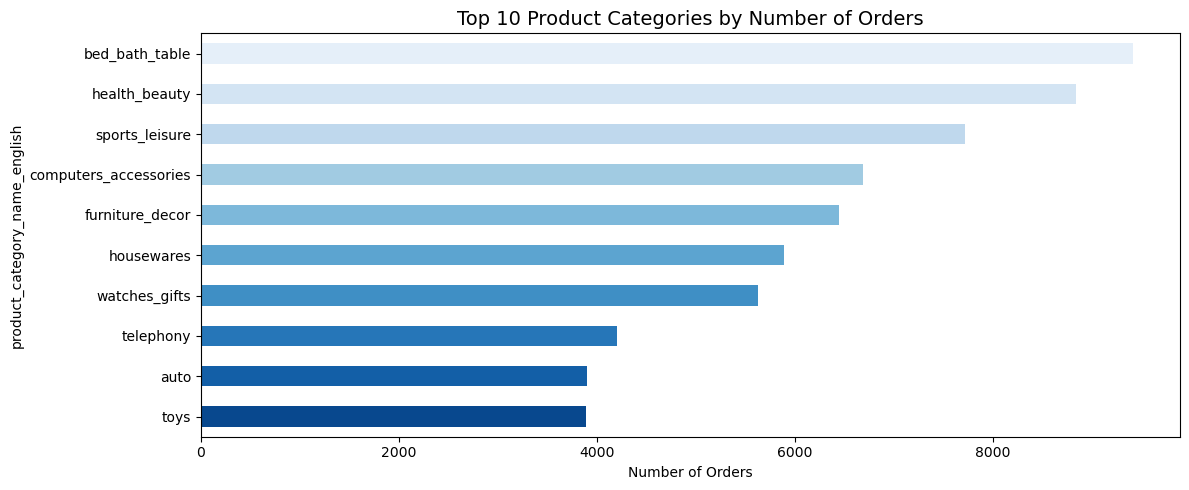

Chart saved: phase1_top_categories.png


In [13]:
top_categories = (
    df[df["product_category_name_english"].notnull()]
    .groupby("product_category_name_english")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)
print(top_categories.to_string())
 
plt.figure(figsize=(12, 5))
top_categories.sort_values().plot(kind="barh", color=sns.color_palette("Blues_r", 10))
plt.title("Top 10 Product Categories by Number of Orders", fontsize=14)
plt.xlabel("Number of Orders")
plt.tight_layout()
plt.savefig("phase1_top_categories.png", dpi=150)
plt.show()
print("Chart saved: phase1_top_categories.png")
 

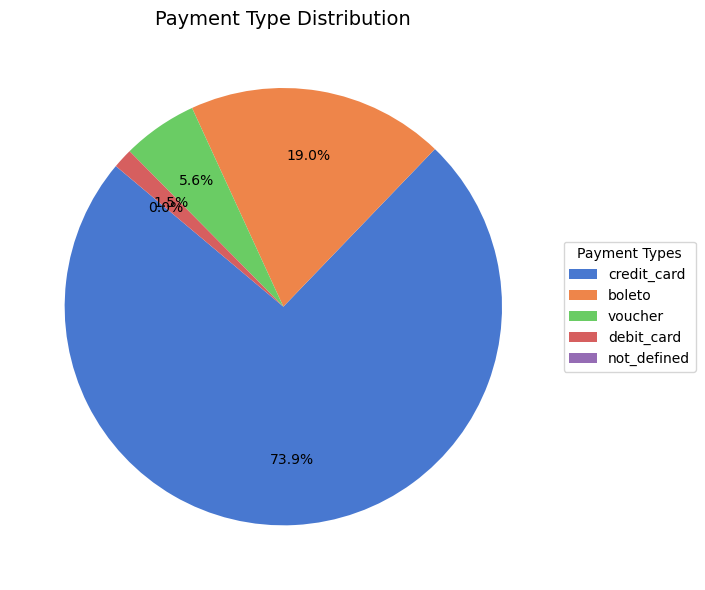

In [14]:
payment_counts = order_payments["payment_type"].value_counts()

plt.figure(figsize=(9, 6))

plt.pie(
    payment_counts,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("muted"),
    pctdistance=0.7
)

plt.title("Payment Type Distribution", fontsize=14)

# Put legend OUTSIDE the chart
plt.legend(
    payment_counts.index,
    title="Payment Types",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.show()

Loaded master dataframe: 119,143 rows
   Delivered orders only:   115,723 rows



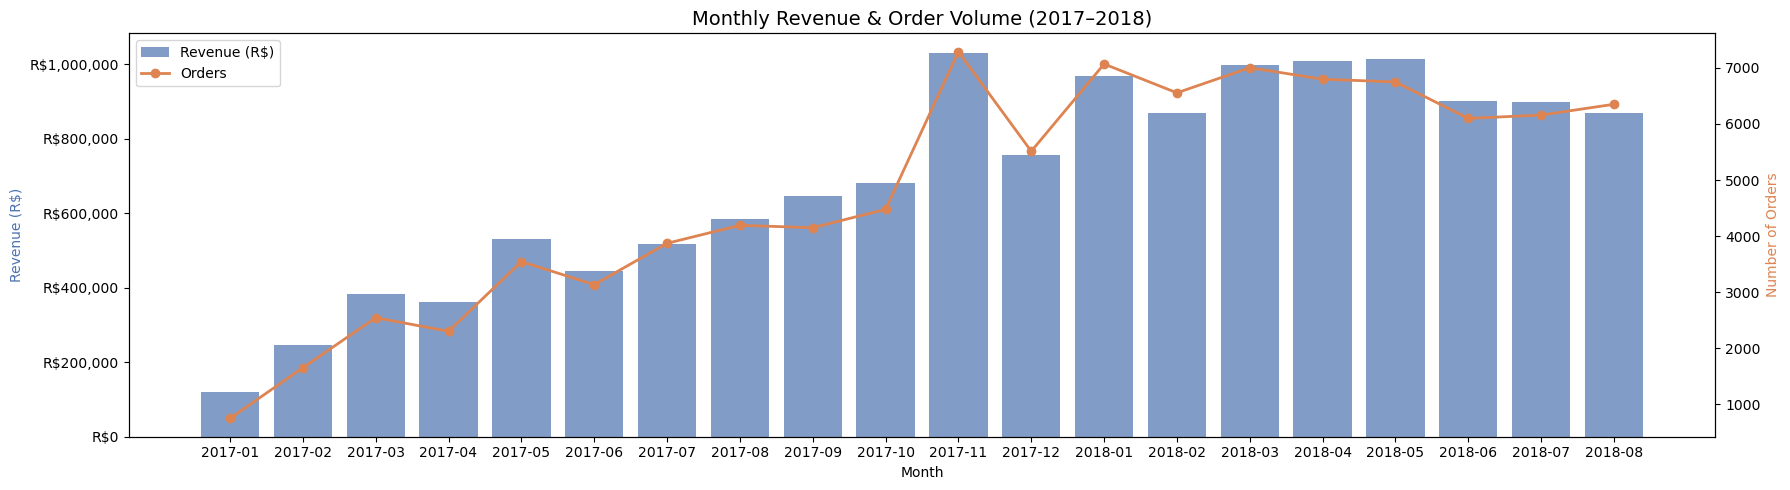

Total Revenue (2017–2018): R$13,834,519.39
Peak Revenue Month: 2017-11
 Saved: phase2_monthly_revenue.png


In [15]:
delivered = df[df["order_status"] == "delivered"].copy()
 
print(f"Loaded master dataframe: {df.shape[0]:,} rows")
print(f"   Delivered orders only:   {delivered.shape[0]:,} rows\n")
# MONTHLY REVENUE TREND
 
monthly_revenue = (
    delivered.groupby(delivered["order_purchase_timestamp"].dt.to_period("M"))
    .agg(
        total_revenue=("price", "sum"),
        total_orders=("order_id", "nunique"),
        avg_order_value=("payment_value", "mean")
    )
    .reset_index()
)
monthly_revenue["period"] = monthly_revenue["order_purchase_timestamp"].astype(str)
 
# Remove incomplete months (2016 only had a few months)
monthly_revenue = monthly_revenue[monthly_revenue["period"] >= "2017-01"]
 
fig, ax1 = plt.subplots(figsize=(18, 5))
ax2 = ax1.twinx()
 
ax1.bar(monthly_revenue["period"], monthly_revenue["total_revenue"],
        color="#4C72B0", alpha=0.7, label="Revenue (R$)")
ax2.plot(monthly_revenue["period"], monthly_revenue["total_orders"],
         color="#DD8452", marker="o", linewidth=2, label="Orders")
 
ax1.set_title("Monthly Revenue & Order Volume (2017–2018)", fontsize=14)
ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue (R$)", color="#4C72B0")
ax2.set_ylabel("Number of Orders", color="#DD8452")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))
plt.xticks(rotation=45, ha="right")
 
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
 
plt.tight_layout()
plt.savefig("phase2_monthly_revenue.png", dpi=150)
plt.show()
 
total_rev = monthly_revenue["total_revenue"].sum()
peak_month = monthly_revenue.loc[monthly_revenue["total_revenue"].idxmax(), "period"]
print(f"Total Revenue (2017–2018): R${total_rev:,.2f}")
print(f"Peak Revenue Month: {peak_month}")
print(" Saved: phase2_monthly_revenue.png")

product_category_name_english  total_revenue  total_orders  avg_price
                health_beauty     1275776.49          8647 129.969080
                watches_gifts     1214620.45          5495 199.871721
               bed_bath_table     1092461.20          9272  92.471745
               sports_leisure      995980.76          7530 113.295502
        computers_accessories      926557.43          6530 116.357834
              furniture_decor      753082.79          6307  87.132106
                   housewares      650395.78          5743  90.382960
                   cool_stuff      636631.49          3559 162.488895
                         auto      604295.84          3810 140.468582
                 garden_tools      493645.87          3448 110.188810


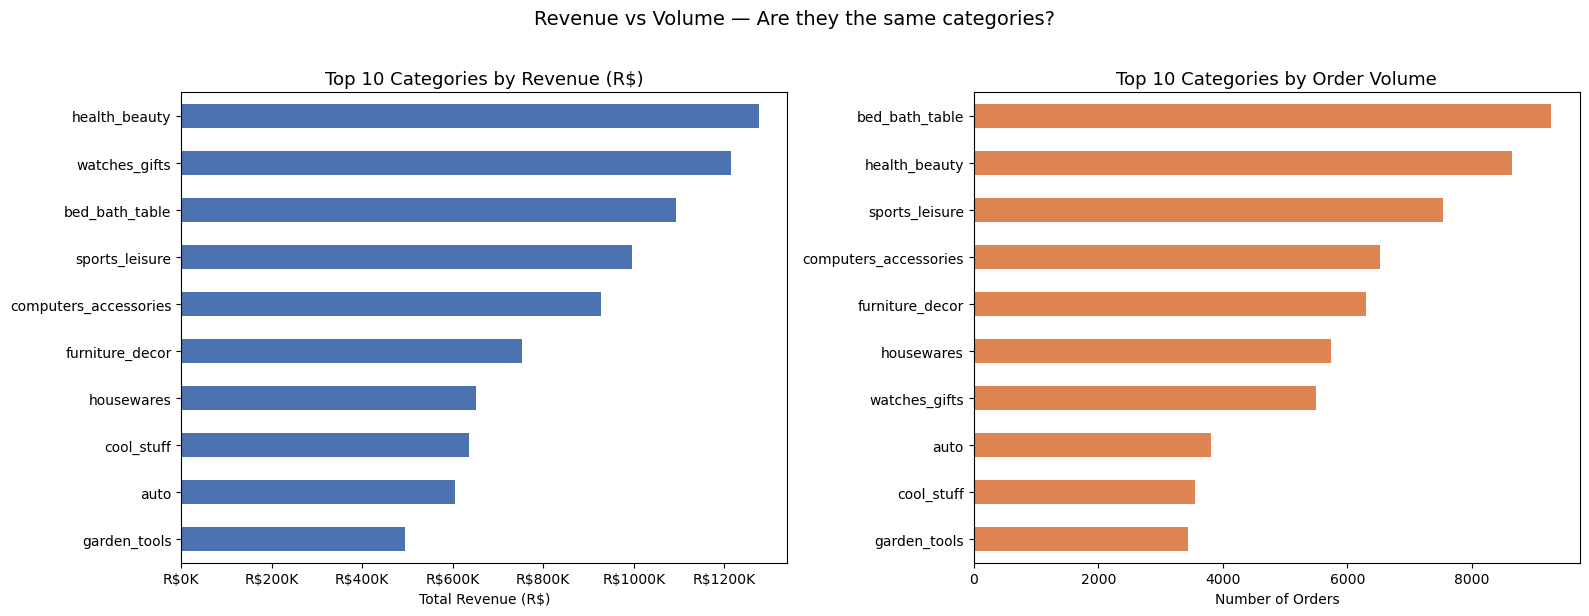

 Saved: phase2_category_revenue.png


In [16]:
#REVENUE BY PRODUCT CATEGORY
category_revenue = (
    delivered.groupby("product_category_name_english")
    .agg(
        total_revenue=("price", "sum"),
        total_orders=("order_id", "nunique"),
        avg_price=("price", "mean")
    )
    .sort_values("total_revenue", ascending=False)
    .head(10)
    .reset_index()
)
print(category_revenue.to_string(index=False))
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# Revenue
category_revenue.sort_values("total_revenue").plot(
    kind="barh", x="product_category_name_english", y="total_revenue",
    ax=axes[0], color="#4C72B0", legend=False
)
axes[0].set_title("Top 10 Categories by Revenue (R$)", fontsize=13)
axes[0].set_xlabel("Total Revenue (R$)")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x/1000:.0f}K"))
 
# Orders
category_revenue.sort_values("total_orders").plot(
    kind="barh", x="product_category_name_english", y="total_orders",
    ax=axes[1], color="#DD8452", legend=False
)
axes[1].set_title("Top 10 Categories by Order Volume", fontsize=13)
axes[1].set_xlabel("Number of Orders")
axes[1].set_ylabel("")
 
plt.suptitle("Revenue vs Volume — Are they the same categories?", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("phase2_category_revenue.png", dpi=150)
plt.show()
print(" Saved: phase2_category_revenue.png")

payment_type  avg_order_value  total_orders  total_revenue
 credit_card       178.848820         74304    15268681.44
      boleto       176.234307         19191     3966153.08
  debit_card       149.027966          1485      247684.48
     voucher        64.621594          3679      399426.07


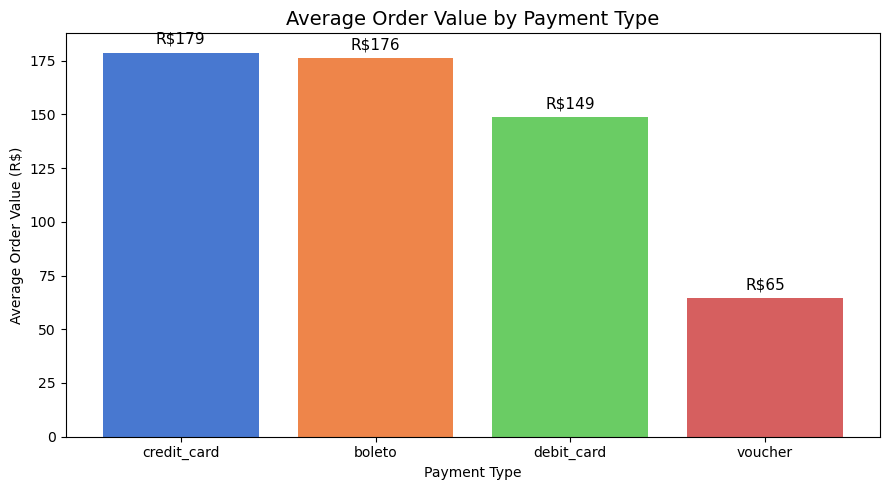

Saved: phase2_aov_payment.png


In [17]:
#AVERAGE ORDER VALUE (AOV) BY PAYMENT TYPE
aov_by_payment = (
    delivered.groupby("payment_type")
    .agg(
        avg_order_value=("payment_value", "mean"),
        total_orders=("order_id", "nunique"),
        total_revenue=("payment_value", "sum")
    )
    .sort_values("avg_order_value", ascending=False)
    .reset_index()
)
print(aov_by_payment.to_string(index=False))
 
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    aov_by_payment["payment_type"],
    aov_by_payment["avg_order_value"],
    color=sns.color_palette("muted", len(aov_by_payment))
)
ax.bar_label(bars, fmt="R$%.0f", padding=4, fontsize=11)
ax.set_title("Average Order Value by Payment Type", fontsize=14)
ax.set_xlabel("Payment Type")
ax.set_ylabel("Average Order Value (R$)")
plt.tight_layout()
plt.savefig("phase2_aov_payment.png", dpi=150)
plt.show()
print("Saved: phase2_aov_payment.png")
 

quarter    revenue  orders    growth_%
 2017Q1  751539.64    4949 1697.194898
 2017Q2 1339459.54    8984   78.228728
 2017Q3 1749655.45   12215   30.623987
 2017Q4 2467439.94   17280   41.024334
 2018Q1 2835868.75   20627   14.931622
 2018Q2 2922665.21   19646    3.060666
 2018Q3 1767890.86   12510  -39.511003


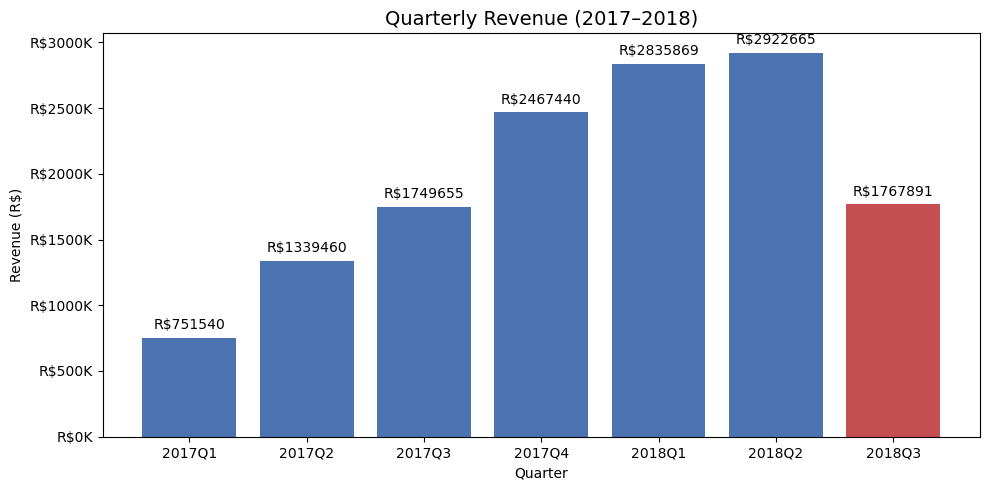

Saved: phase2_quarterly_revenue.png


In [18]:
#QUARTERLY REVENUE GROWTH
delivered["quarter"] = delivered["order_purchase_timestamp"].dt.to_period("Q")
quarterly = (
    delivered.groupby("quarter")
    .agg(revenue=("price", "sum"), orders=("order_id", "nunique"))
    .reset_index()
)
quarterly["quarter"] = quarterly["quarter"].astype(str)
quarterly["growth_%"] = quarterly["revenue"].pct_change() * 100
quarterly = quarterly[quarterly["quarter"] >= "2017Q1"]
print(quarterly.to_string(index=False))
 
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(quarterly["quarter"], quarterly["revenue"],
              color=["#4C72B0" if g >= 0 or pd.isna(g) else "#C44E52"
                     for g in quarterly["growth_%"]])
ax.bar_label(bars, fmt="R$%.0f", padding=4, fontsize=10)
ax.set_title("Quarterly Revenue (2017–2018)", fontsize=14)
ax.set_xlabel("Quarter")
ax.set_ylabel("Revenue (R$)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x/1000:.0f}K"))
plt.tight_layout()
plt.savefig("phase2_quarterly_revenue.png", dpi=150)
plt.show()
print("Saved: phase2_quarterly_revenue.png")
 

customer_state  avg_freight  total_orders
       Paraíba    43.587420           517
       Roraima    43.088043            41
      Rondônia    41.221815           243
          Acre    39.996489            80
     Tocantins    39.888563           274
         Piauí    39.198791           476
      Maranhão    38.450632           717
       Sergipe    36.584948           335
       Alagoas    35.661933           397
          Pará    35.449344           946


C:\Users\benso\AppData\Local\Temp\ipykernel_26288\1586569194.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=freight_by_state, x="customer_state", y="avg_freight",


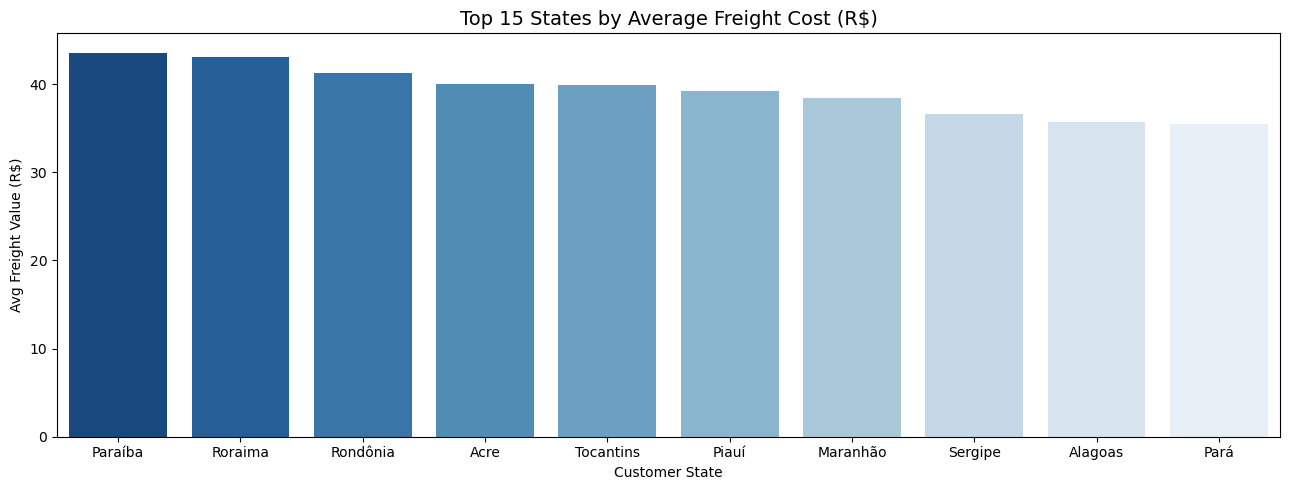

Saved: phase2_freight_by_state.png


In [19]:
#FREIGHT COST BY STATE
freight_by_state = (
    delivered.groupby("customer_state")
    .agg(
        avg_freight=("freight_value", "mean"),
        total_orders=("order_id", "nunique")
    )
    .sort_values("avg_freight", ascending=False)
    .head(10)
    .reset_index()
)
print(freight_by_state.to_string(index=False))
 
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=freight_by_state, x="customer_state", y="avg_freight",
            palette="Blues_r", ax=ax)
ax.set_title("Top 15 States by Average Freight Cost (R$)", fontsize=14)
ax.set_xlabel("Customer State")
ax.set_ylabel("Avg Freight Value (R$)")
plt.tight_layout()
plt.savefig("phase2_freight_by_state.png", dpi=150)
plt.show()
print("Saved: phase2_freight_by_state.png")

 

In [20]:
sql_summary = delivered.groupby("product_category_name_english").agg(
    total_revenue   = ("price", "sum"),
    total_orders    = ("order_id", "nunique"),
    avg_price       = ("price", "mean"),
    avg_freight     = ("freight_value", "mean"),
    avg_review      = ("review_score",  "mean")
).round(2).sort_values("total_revenue", ascending=False).head(15)
 
print(sql_summary.to_string())
sql_summary.to_csv("phase2_category_summary.csv")
print("\n Saved: phase2_category_summary.csv")

                               total_revenue  total_orders  avg_price  avg_freight  avg_review
product_category_name_english                                                                 
health_beauty                     1275776.49          8647     129.97        18.91        4.19
watches_gifts                     1214620.45          5495     199.87        16.80        4.07
bed_bath_table                    1092461.20          9272      92.47        18.39        3.92
sports_leisure                     995980.76          7530     113.30        19.38        4.16
computers_accessories              926557.43          6530     116.36        18.95        3.99
furniture_decor                    753082.79          6307      87.13        20.67        3.96
housewares                         650395.78          5743      90.38        21.00        4.12
cool_stuff                         636631.49          3559     162.49        21.80        4.19
auto                               604295.84      

In [21]:
top_cat     = category_revenue.iloc[0]["product_category_name_english"]
top_cat_rev = category_revenue.iloc[0]["total_revenue"]
top_payment = aov_by_payment.iloc[0]["payment_type"]
top_aov     = aov_by_payment.iloc[0]["avg_order_value"]
top_state   = freight_by_state.iloc[0]["customer_state"]
 
print(f"""
  1.  Revenue grew consistently from 2017 Q1 through 2018
  2. Top category by revenue: {top_cat} (R${top_cat_rev:,.0f})
  3. Highest AOV payment type: {top_payment} (R${top_aov:,.0f} avg)
  4. Highest freight costs in: {top_state} — potential logistics issue
  5. Credit cards drive 73.9% of orders but check if they also
        drive the highest revenue per order
        """)


  1.  Revenue grew consistently from 2017 Q1 through 2018
  2. Top category by revenue: health_beauty (R$1,275,776)
  3. Highest AOV payment type: credit_card (R$179 avg)
  4. Highest freight costs in: Paraíba — potential logistics issue
  5. Credit cards drive 73.9% of orders but check if they also
        drive the highest revenue per order
        


In [22]:
#CALCULATE RFM VALUES
# RFM stands for:
#   Recency   — how recently did the customer last buy?
#   Frequency — how many times have they bought?
#   Monetary  — how much have they spent in total?
# Use the most recent order date in the dataset as "today"
snapshot_date = delivered["order_purchase_timestamp"].max() + pd.Timedelta(days=1)
print(f"   Snapshot date (reference point): {snapshot_date.date()}")
 
rfm = (
    delivered.groupby("customer_unique_id")
    .agg(
        recency   = ("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
        frequency = ("order_id",                 "nunique"),
        monetary  = ("payment_value",            "sum")
    )
    .reset_index()
)
 
print(f"\n   Total unique customers: {rfm.shape[0]:,}")
print("\n   RFM Summary Statistics:")
print(rfm[["recency", "frequency", "monetary"]].describe().round(2).to_string())

   Snapshot date (reference point): 2018-08-30

   Total unique customers: 93,358

   RFM Summary Statistics:
        recency  frequency   monetary
count  93358.00   93358.00   93358.00
mean     237.94       1.03     212.96
std      152.59       0.21     646.22
min        1.00       1.00       0.00
25%      114.00       1.00      63.83
50%      219.00       1.00     113.14
75%      346.00       1.00     202.64
max      714.00      15.00  109312.64


In [23]:
# SCORE EACH CUSTOMER 1–5 ON R, F, M
# Score 5 = best, Score 1 = worst
# Recency:  lower days = better = score 5
# Frequency: higher orders = better = score 5
# Monetary:  higher spend = better = score 5
 
rfm["R_score"] = pd.qcut(rfm["recency"],   q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M_score"] = pd.qcut(rfm["monetary"],  q=5, labels=[1, 2, 3, 4, 5]).astype(int)
 
# Combined RFM score
rfm["RFM_score"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)
rfm["RFM_total"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]
 
print("RFM scores calculated")
print(rfm[["customer_unique_id", "recency", "frequency", "monetary",
           "R_score", "F_score", "M_score", "RFM_total"]].head(10).to_string(index=False))
 

RFM scores calculated
              customer_unique_id  recency  frequency  monetary  R_score  F_score  M_score  RFM_total
0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90        4        1        4          9
0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19        4        1        1          6
0000f46a3911fa3c0805444483337064      537          1     86.22        1        1        2          4
0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62        2        1        1          4
0004aac84e0df4da2b147fca70cf8255      288          1    196.89        2        1        4          7
0004bd2a26a76fe21f786e4fbd80607f      146          1    166.98        4        1        4          9
00050ab1314c0e55a6ca13cf7181fecf      132          1     35.38        4        1        1          6
00053a61a98854899e70ed204dd4bafe      183          1    838.36        3        1        5          9
0005e1862207bf6ccc02e4228effd9a0      543          1    150.12       

In [24]:
#ASSIGN CUSTOMER SEGMENTS
def assign_segment(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 3 and f >= 3 and m >= 3:
        return "Loyal Customers"
    elif r >= 4 and f <= 2:
        return "New Customers"
    elif r >= 3 and f >= 2 and m >= 2:
        return "Potential Loyalists"
    elif r == 3 and f <= 2:
        return "Promising"
    elif r <= 2 and f >= 3 and m >= 3:
        return "At Risk"
    elif r <= 2 and f >= 2 and m >= 2:
        return "Need Attention"
    elif r == 1 and f == 1:
        return "Lost"
    else:
        return "Hibernating"
 
rfm["segment"] = rfm.apply(assign_segment, axis=1)
 
segment_summary = (
    rfm.groupby("segment")
    .agg(
        customer_count = ("customer_unique_id", "count"),
        avg_recency    = ("recency",            "mean"),
        avg_frequency  = ("frequency",          "mean"),
        avg_monetary   = ("monetary",           "mean"),
        total_revenue  = ("monetary",           "sum")
    )
    .round(2)
    .sort_values("total_revenue", ascending=False)
    .reset_index()
)
 
segment_summary["revenue_%"] = (
    segment_summary["total_revenue"] / segment_summary["total_revenue"].sum() * 100
).round(1)
 
print(segment_summary.to_string(index=False))
 

            segment  customer_count  avg_recency  avg_frequency  avg_monetary  total_revenue  revenue_%
            At Risk           13244       393.54           1.07        321.96     4264035.92       21.4
    Loyal Customers           14206       153.40           1.06        269.39     3826935.07       19.2
      New Customers           14984        90.88           1.00        204.42     3062988.48       15.4
          Champions            6462        91.05           1.18        444.34     2871304.33       14.4
     Need Attention           10577       392.87           1.01        175.80     1859471.98        9.4
        Hibernating           16269       271.58           1.00         84.52     1375108.93        6.9
Potential Loyalists            9299       161.14           1.01        120.13     1117053.14        5.6
               Lost            3827       474.08           1.00        199.44      763271.49        3.8
          Promising            4490       219.58           1.00 

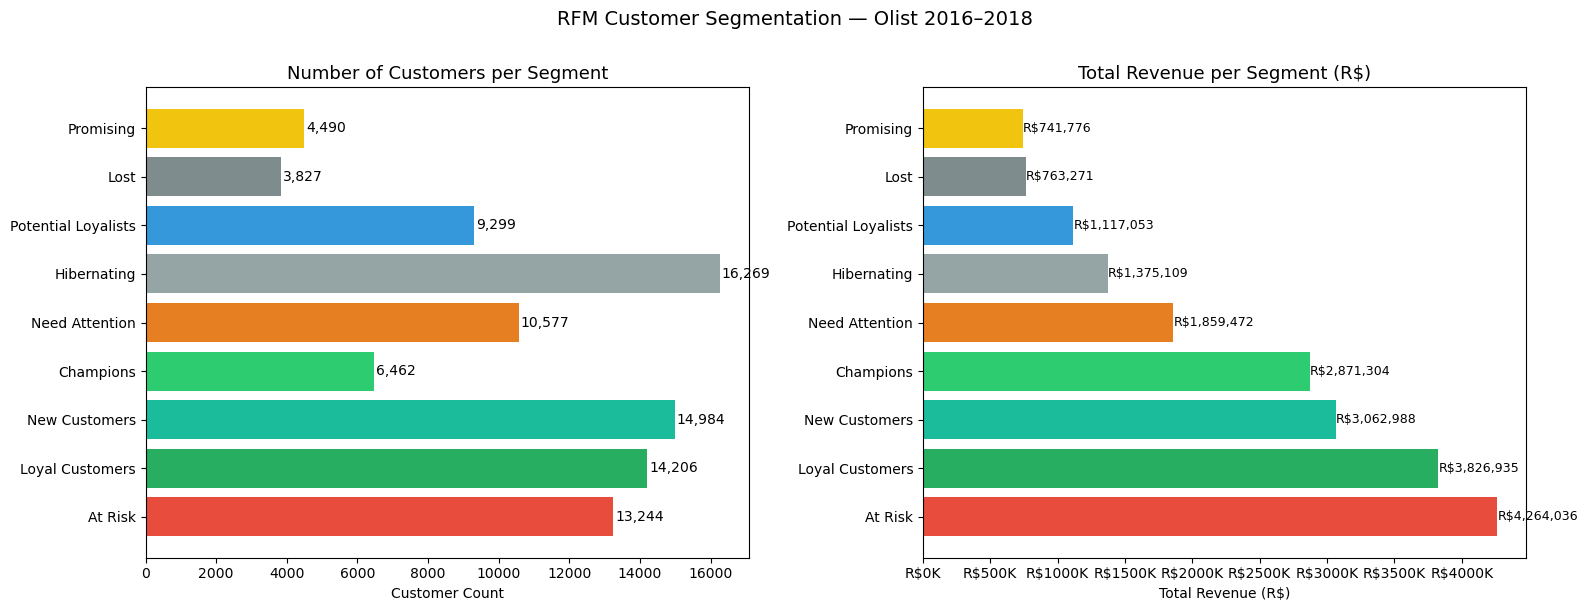

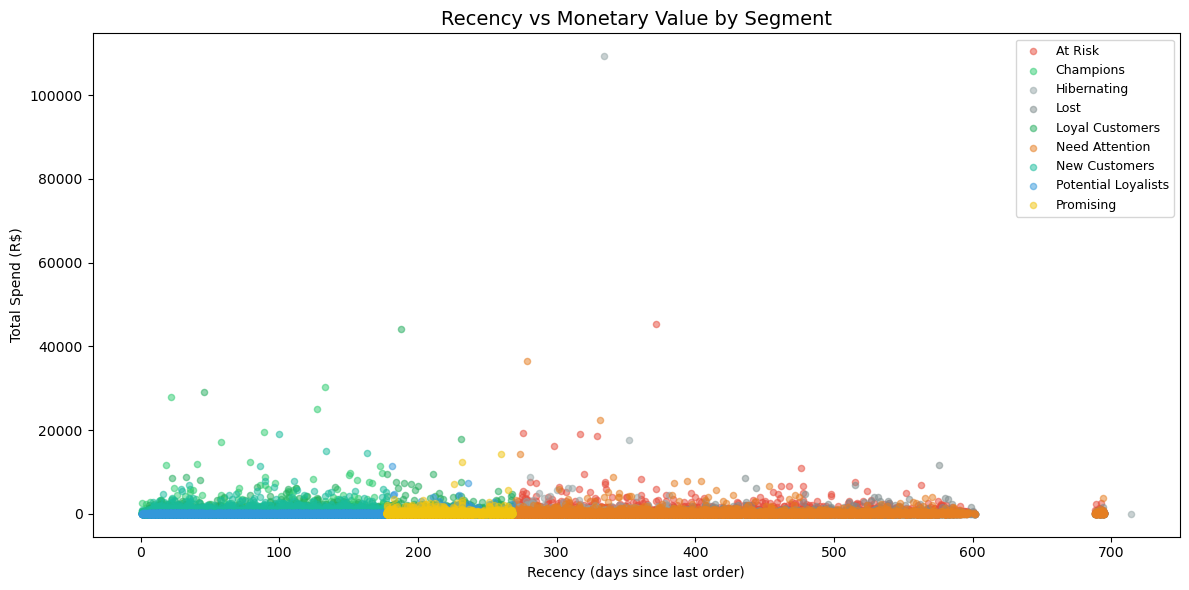

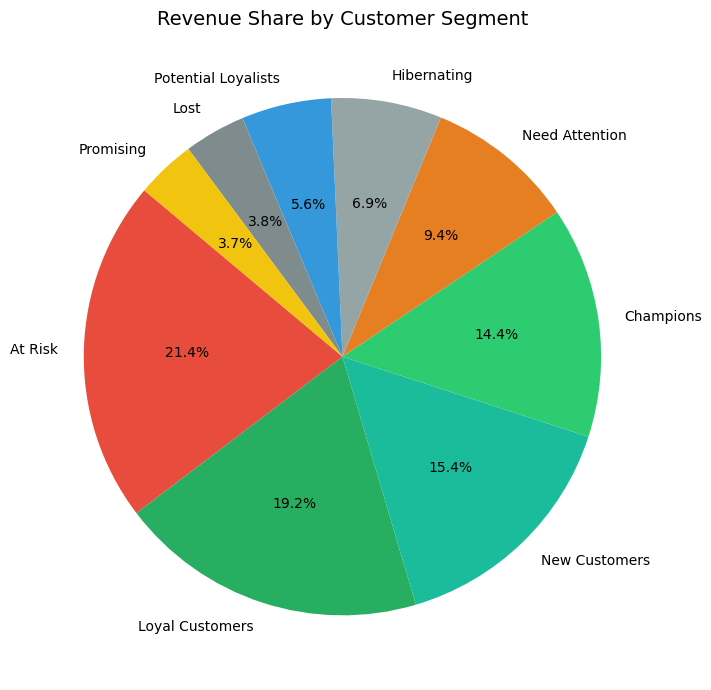

In [25]:
#VISUALISE SEGMENT SIZE
segment_colors = {
    "Champions":          "#2ecc71",
    "Loyal Customers":    "#27ae60",
    "Potential Loyalists":"#3498db",
    "New Customers":      "#1abc9c",
    "Promising":          "#f1c40f",
    "Need Attention":     "#e67e22",
    "At Risk":            "#e74c3c",
    "Hibernating":        "#95a5a6",
    "Lost":               "#7f8c8d"
}
 
colors = [segment_colors.get(s, "#bdc3c7") for s in segment_summary["segment"]]
 
#Customer count per segment
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
axes[0].barh(segment_summary["segment"], segment_summary["customer_count"], color=colors)
axes[0].set_title("Number of Customers per Segment", fontsize=13)
axes[0].set_xlabel("Customer Count")
for i, v in enumerate(segment_summary["customer_count"]):
    axes[0].text(v + 50, i, f"{v:,}", va="center", fontsize=10)
 
# Revenue per segment
axes[1].barh(segment_summary["segment"], segment_summary["total_revenue"], color=colors)
axes[1].set_title("Total Revenue per Segment (R$)", fontsize=13)
axes[1].set_xlabel("Total Revenue (R$)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x/1000:.0f}K"))
for i, v in enumerate(segment_summary["total_revenue"]):
    axes[1].text(v + 100, i, f"R${v:,.0f}", va="center", fontsize=9)
 
plt.suptitle("RFM Customer Segmentation — Olist 2016–2018", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

 
 
# Chart 3 RFM Scatter: Recency vs Monetary coloured by segment
fig, ax = plt.subplots(figsize=(12, 6))
for segment, group in rfm.groupby("segment"):
    ax.scatter(
        group["recency"], group["monetary"],
        label=segment, alpha=0.5, s=20,
        color=segment_colors.get(segment, "#bdc3c7")
    )
ax.set_title("Recency vs Monetary Value by Segment", fontsize=14)
ax.set_xlabel("Recency (days since last order)")
ax.set_ylabel("Total Spend (R$)")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()
 
 
# Chart 4 Revenue share pie chart
fig, ax = plt.subplots(figsize=(9, 7))
ax.pie(
    segment_summary["total_revenue"],
    labels=segment_summary["segment"],
    autopct="%1.1f%%",
    colors=colors,
    startangle=140
)
ax.set_title("Revenue Share by Customer Segment", fontsize=14)
plt.tight_layout()
plt.show()

In [26]:
# STEP 5: BUSINESS RECOMMENDATIONS PER SEGMENT
recommendations = {
    "Champions":           "Reward them. They are your best customers offer loyalty rewards and early access to new products.",
    "Loyal Customers":     "Upsell higher value products. They trust the brand push premium categories.",
    "Potential Loyalists": "Offer membership or loyalty programs to convert them into Loyal Customers.",
    "New Customers":       "Onboard well. Send welcome emails, product guides, and first-purchase discounts.",
    "Promising":           "Build relationship. Send personalised recommendations based on first purchase.",
    "Need Attention":      "Re-engage with targeted offers before they slip to At Risk.",
    "At Risk":             "Send win-back campaigns. Remind them what they loved — offer a discount.",
    "Hibernating":         "Share new product updates. Low-cost email campaign to see if they respond.",
    "Lost":                "Minimal spend here. Try one last re-engagement email, then move on."
}
 
for segment, rec in recommendations.items():
    count = segment_summary.loc[segment_summary["segment"] == segment, "customer_count"].values
    count_str = f"{count[0]:,}" if len(count) > 0 else "N/A"
    print(f"\n  [{segment}] ({count_str} customers)")
    print(f"   {rec}")


  [Champions] (6,462 customers)
   Reward them. They are your best customers offer loyalty rewards and early access to new products.

  [Loyal Customers] (14,206 customers)
   Upsell higher value products. They trust the brand push premium categories.

  [Potential Loyalists] (9,299 customers)
   Offer membership or loyalty programs to convert them into Loyal Customers.

  [New Customers] (14,984 customers)
   Onboard well. Send welcome emails, product guides, and first-purchase discounts.

  [Promising] (4,490 customers)
   Build relationship. Send personalised recommendations based on first purchase.

  [Need Attention] (10,577 customers)
   Re-engage with targeted offers before they slip to At Risk.

  [At Risk] (13,244 customers)
   Send win-back campaigns. Remind them what they loved — offer a discount.

  [Hibernating] (16,269 customers)
   Share new product updates. Low-cost email campaign to see if they respond.

  [Lost] (3,827 customers)
   Minimal spend here. Try one last r

   Total delivered orders: 115,104
   On time or early:       106,960 (92.9%)
   Late deliveries:        8,144 (7.1%)
   Avg actual delivery:    11.8 days
   Avg estimated delivery: 23.3 days


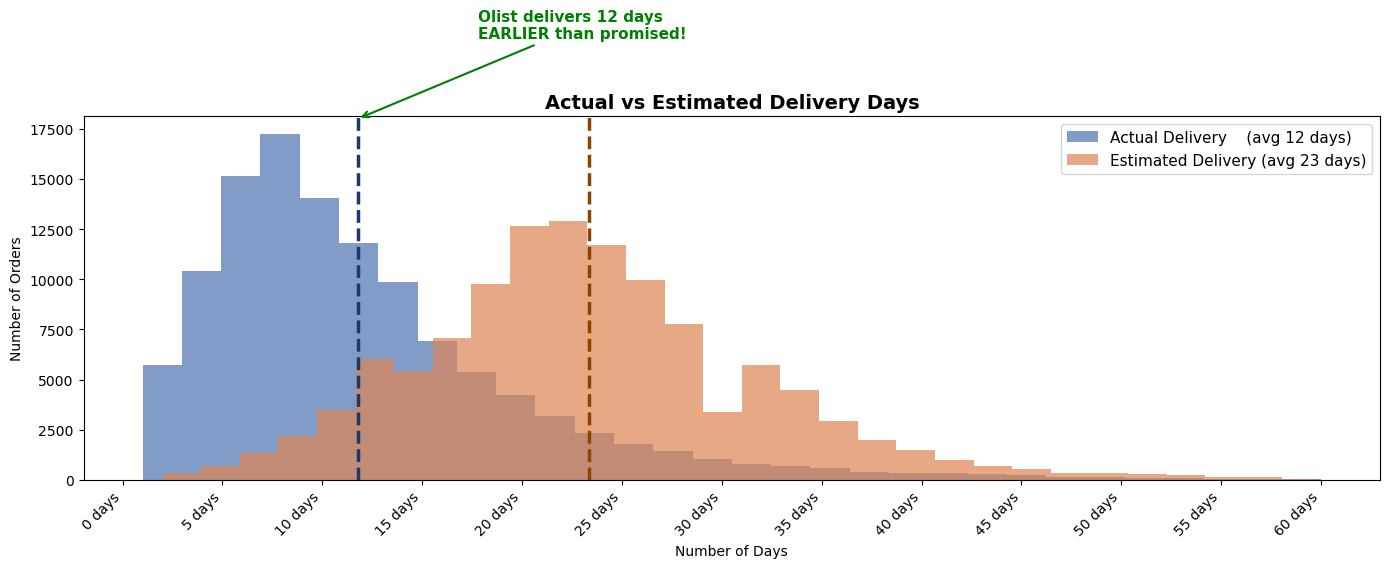

In [27]:
# ACTUAL VS ESTIMATED DELIVERY TIME
for col in ["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]:
    delivered[col] = pd.to_datetime(delivered[col])

delivered["actual_delivery_days"]    = (delivered["order_delivered_customer_date"] - delivered["order_purchase_timestamp"]).dt.days
delivered["estimated_delivery_days"] = (delivered["order_estimated_delivery_date"] - delivered["order_purchase_timestamp"]).dt.days
delivered["is_late"]                 = delivered["actual_delivery_days"] > delivered["estimated_delivery_days"]
delivered["delivery_diff"]           = delivered["estimated_delivery_days"] - delivered["actual_delivery_days"]

delivered = delivered.dropna(subset=["actual_delivery_days", "estimated_delivery_days"])
delivered = delivered[delivered["actual_delivery_days"].between(1, 60) & delivered["estimated_delivery_days"].between(1, 60)]

total, late_orders = len(delivered), delivered["is_late"].sum()
on_time = total - late_orders

print(f"   Total delivered orders: {total:,}")
print(f"   On time or early:       {on_time:,} ({on_time/total*100:.1f}%)")
print(f"   Late deliveries:        {late_orders:,} ({late_orders/total*100:.1f}%)")
print(f"   Avg actual delivery:    {delivered['actual_delivery_days'].mean():.1f} days")
print(f"   Avg estimated delivery: {delivered['estimated_delivery_days'].mean():.1f} days")

avg_actual    = delivered["actual_delivery_days"].mean()
avg_estimated = delivered["estimated_delivery_days"].mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.hist(delivered["actual_delivery_days"],    bins=30, alpha=0.7, color="#4C72B0", label=f"Actual Delivery    (avg {avg_actual:.0f} days)")
ax.hist(delivered["estimated_delivery_days"], bins=30, alpha=0.7, color="#DD8452", label=f"Estimated Delivery (avg {avg_estimated:.0f} days)")
ax.axvline(avg_actual,    color="#1a3a6b", linewidth=2.5, linestyle="--")
ax.axvline(avg_estimated, color="#8B4500", linewidth=2.5, linestyle="--")
ax.annotate(
    f"Olist delivers {avg_estimated - avg_actual:.0f} days\nEARLIER than promised!",
    xy=(avg_actual, 18000), xytext=(avg_actual + 6, 22000),
    fontsize=11, color="green", fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="green", lw=1.5)
)
ax.set_title("Actual vs Estimated Delivery Days", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Days")
ax.set_ylabel("Number of Orders")
ax.set_xticks(range(0, 65, 5))
ax.set_xticklabels([f"{i} days" for i in range(0, 65, 5)], rotation=45, ha="right")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

     customer_state  total_orders  late_orders  avg_delay_days  late_%
            Alagoas           390          102        7.968037    26.2
           Maranhão           703          156        8.924035    22.2
            Sergipe           330           58       10.401575    17.6
              Piauí           470           80       11.569343    17.0
              Ceará          1251          199       11.337627    15.9
              Bahia          3218          474       10.814121    14.7
     Rio de Janeiro         12229         1750       11.743744    14.3
          Tocantins           272           37       11.658610    13.6
     Espírito Santo          1981          262       10.267361    13.2
               Pará           924          120       14.009363    13.0
            Paraíba           511           66       12.744337    12.9
Rio Grande do Norte           463           58       13.180000    12.5
 Mato Grosso do Sul           700           85       10.571429    12.1
      

C:\Users\benso\AppData\Local\Temp\ipykernel_26288\1364577729.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=late_by_state, x="customer_state", y="late_%",


NameError: name 'save_plot' is not defined

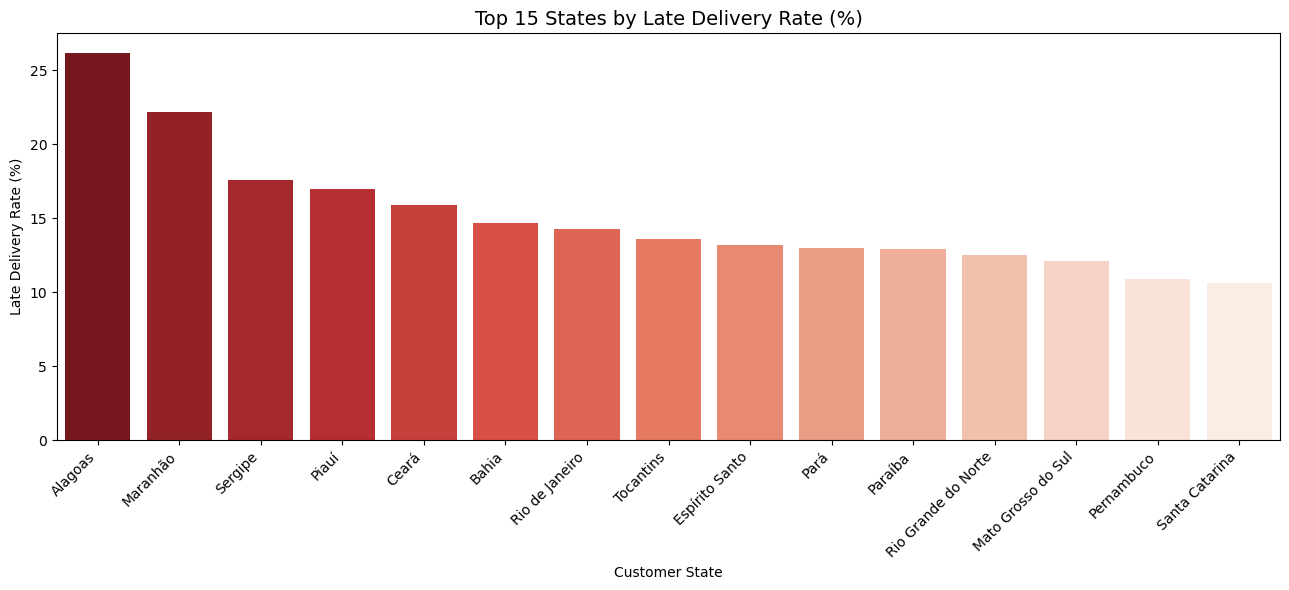

In [28]:
#LATE DELIVERIES BY STATE
late_by_state = (
    delivered.groupby("customer_state")
    .agg(
        total_orders   = ("order_id",      "nunique"),
        late_orders    = ("is_late",       "sum"),
        avg_delay_days = ("delivery_diff", "mean")
    )
    .reset_index()
)
late_by_state["late_%"] = (
    late_by_state["late_orders"] / late_by_state["total_orders"] * 100
).round(1)
late_by_state = late_by_state.sort_values("late_%", ascending=False).head(15)
 
print(late_by_state.to_string(index=False))
 
fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=late_by_state, x="customer_state", y="late_%",
            palette="Reds_r", ax=ax)
ax.set_title("Top 15 States by Late Delivery Rate (%)", fontsize=14)
ax.set_xlabel("Customer State")
ax.set_ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
save_plot("phase4_late_by_state.png")
plt.show()

In [ ]:
#DELIVERY TIME VS REVIEW SCORE 
delivery_review = (
    delivered.groupby("review_score")
    .agg(
        avg_delivery_days  = ("actual_delivery_days",   "mean"),
        avg_estimated_days = ("estimated_delivery_days","mean"),
        order_count        = ("order_id",               "nunique"),
        late_rate          = ("is_late",                "mean")
    )
    .reset_index()
    .round(2)
)
print(delivery_review.to_string(index=False))
 
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
 
ax1.bar(delivery_review["review_score"], delivery_review["avg_delivery_days"],
        color="#4C72B0", alpha=0.7, label="Avg Delivery Days")
ax2.plot(delivery_review["review_score"], delivery_review["late_rate"] * 100,
         color="#C44E52", marker="o", linewidth=2, label="Late Rate (%)")
 
ax1.set_title("Delivery Time & Late Rate vs Customer Review Score", fontsize=14)
ax1.set_xlabel("Review Score (1=Worst, 5=Best)")
ax1.set_ylabel("Avg Delivery Days", color="#4C72B0")
ax2.set_ylabel("Late Delivery Rate (%)", color="#C44E52")
 
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.show()

TOP 10 SELLERS:
                       seller_id  total_orders  avg_review_score  avg_delivery_days  late_rate  total_revenue
48efc9d94a9834137efd9ea76b065a38            33              5.00              10.59       0.00         345.60
2addf05f476d0637864454e93ba673d5            12              5.00              10.00       0.00        4552.00
b1fecf4da1fa2689bccffa0121953643            19              4.97              11.13       0.00        5518.64
41c2bad7229b0c25e6becf179ebf63ff            20              4.96               4.30       0.00         782.00
9d681c7e12db302cb261e721040dde65            13              4.93               8.50       0.00         785.60
334cab711dee080b079fa5779b584783            11              4.93               6.20       0.00        1269.30
d4910f1cdcfdabd48d6b316e395d4a23            11              4.92               5.67       0.08        1146.88
2d518637f53161b973e01f56ea4bb88e            12              4.92              11.92       0.00        11

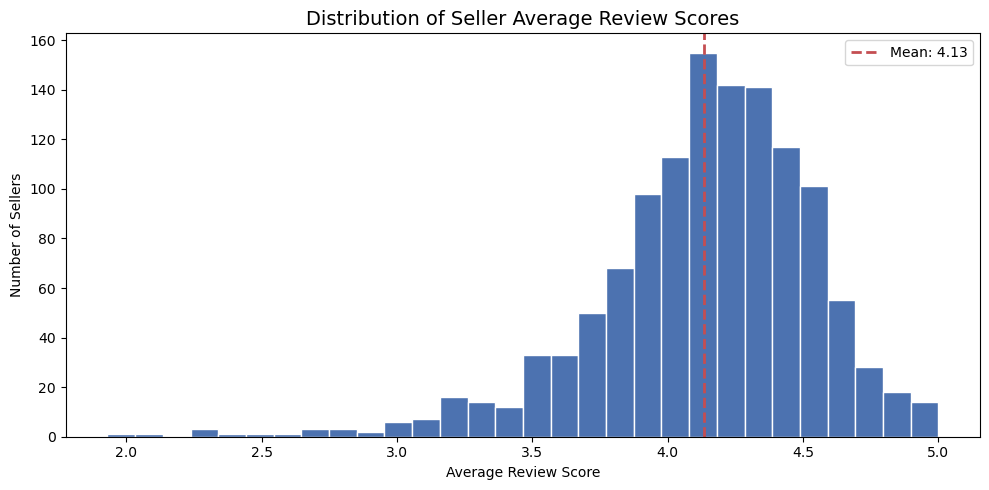

In [33]:
#TOP & BOTTOM PERFORMING SELLERS
seller_performance = (
    delivered.groupby("seller_id")
    .agg(
        total_orders      = ("order_id",             "nunique"),
        avg_review_score  = ("review_score",         "mean"),
        avg_delivery_days = ("actual_delivery_days", "mean"),
        late_rate         = ("is_late",              "mean"),
        total_revenue     = ("price",                "sum")
    )
    .reset_index()
    .round(2)
)
 
seller_performance = seller_performance[seller_performance["total_orders"] >= 10]
 
top_sellers    = seller_performance.sort_values("avg_review_score", ascending=False).head(10)
bottom_sellers = seller_performance.sort_values("avg_review_score").head(10)
 
print("TOP 10 SELLERS:")
print(top_sellers[["seller_id","total_orders","avg_review_score",
                   "avg_delivery_days","late_rate","total_revenue"]].to_string(index=False))
 
print("\nBOTTOM 10 SELLERS:")
print(bottom_sellers[["seller_id","total_orders","avg_review_score",
                       "avg_delivery_days","late_rate","total_revenue"]].to_string(index=False))
 
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(seller_performance["avg_review_score"], bins=30,
        color="#4C72B0", edgecolor="white")
ax.axvline(seller_performance["avg_review_score"].mean(),
           color="#C44E52", linewidth=2, linestyle="--",
           label=f'Mean: {seller_performance["avg_review_score"].mean():.2f}')
ax.set_title("Distribution of Seller Average Review Scores", fontsize=14)
ax.set_xlabel("Average Review Score")
ax.set_ylabel("Number of Sellers")
ax.legend()
plt.tight_layout()
plt.show()

In [35]:
#PHASE 4 COMPLETE KEY INSIGHTS
late_pct      = late_orders / total * 100
avg_actual    = delivered["actual_delivery_days"].mean()
avg_estimated = delivered["estimated_delivery_days"].mean()
worst_state   = late_by_state.iloc[0]["customer_state"]
worst_late    = late_by_state.iloc[0]["late_%"]
 
print(f"""
  1. Average actual delivery:   {avg_actual:.1f} days
     Average estimated delivery: {avg_estimated:.1f} days
     Olist is generally delivering faster than estimated
 
  2. {late_pct:.1f}% of orders are delivered late
     Worth investigating which sellers drive this
 
  3. Worst state for late deliveries: {worst_state} ({worst_late}% late rate)
     Remote northern/northeastern states suffer most
 
  4. Low review scores strongly correlate with late deliveries
     Improving delivery time is the #1 lever for better reviews
 
  5. Seller performance varies widely
     Bottom sellers should be flagged for quality review
 
""")


  1. Average actual delivery:   11.8 days
     Average estimated delivery: 23.3 days
     Olist is generally delivering faster than estimated
 
  2. 7.1% of orders are delivered late
     Worth investigating which sellers drive this
 
  3. Worst state for late deliveries: Alagoas (26.2% late rate)
     Remote northern/northeastern states suffer most
 
  4. Low review scores strongly correlate with late deliveries
     Improving delivery time is the #1 lever for better reviews
 
  5. Seller performance varies widely
     Bottom sellers should be flagged for quality review
 

